# Ligand-Receptor Experiment

Two-population simulation with fast ligands, slow receptors, type-specific spot widths, and simple binding/unbinding dynamics.

In [ ]:
%cd ..
%load_ext autoreload
%autoreload 2
from helpers.helpersGeneration import *
from helpers.helpersSimulation import *
from helpers.helpersTracking import *
from helpers.helpersStatistics import *
from helpers.helpersAssignment import *
from helpers.helpersPlotting import *

import copy
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## I. Simulation of the receptors and ligands interactions

In [ ]:
simulation_config = {
    "n_ligands": 10,
    "n_receptors": 5,
    "nframes": 100,
    "nposframe": 5,
    "dt": 1.0,
    "ligand_D": [(4.0, 0.4), (8.0, 0.6)],
    "receptor_D": [(0.0, 0.9), (0.02, 0.1)],
    "frame_size": (128, 128),
    "boundary_margin": 10,
    "binding_radius": 8.0,
    "kon": 3.0,
    "koff": 0.02,
    "allow_multiple_ligands_per_receptor": False,
    "bound_position_noise": 0.15,
    "ligand_intensity_mean": 750,
    "ligand_intensity_std": 100,
    "receptor_intensity_mean": 750,
    "receptor_intensity_std": 150,
    "ligand_sigma_mean": 0.65,
    "ligand_sigma_std": 0.05,
    "receptor_sigma_mean": 1.55,
    "receptor_sigma_std": 0.08,
}

image_config = {
    "particle_intensity": [700, 300],
    "particle_sigma": [1.0, 0.2],
    "particle_type_props": {
        "ligand": {
            "particle_intensity": [750, 100],
            "particle_sigma": [0.65, 0.05],
        },
        "receptor": {
            "particle_intensity": [750, 150],
            "particle_sigma": [1.55, 0.08],
        },
    },
    "use_trajectory_sigma": True,
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim = LigandReceptorSimulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR
trajectories_GT = sim.trajectories_GT
ligands_GT = sim.get_ligands()
receptors_GT = sim.get_receptors()
binding_events = sim.binding_events
video_ligand_receptor = sim.video

In [13]:
print(f"Ligands: {len(ligands_GT)}")
print(f"Receptors: {len(receptors_GT)}")
print(f"Binding events: {len(binding_events)}")

if binding_events:
    durations = [event["end_subframe"] - event["start_subframe"] + 1 for event in binding_events]
    print(f"Mean bound duration: {np.mean(durations):.2f} subframes")
    print(binding_events[:5])

Ligands: 10
Receptors: 5
Binding events: 17
Mean bound duration: 98.29 subframes
[{'ligand_id': 7, 'receptor_id': 3, 'start_subframe': 0, 'end_subframe': 282, 'start_frame': 0, 'end_frame': 56}, {'ligand_id': 12, 'receptor_id': 2, 'start_subframe': 2, 'end_subframe': 257, 'start_frame': 0, 'end_frame': 51}, {'ligand_id': 8, 'receptor_id': 4, 'start_subframe': 52, 'end_subframe': 180, 'start_frame': 10, 'end_frame': 36}, {'ligand_id': 8, 'receptor_id': 4, 'start_subframe': 181, 'end_subframe': 181, 'start_frame': 36, 'end_frame': 36}, {'ligand_id': 8, 'receptor_id': 4, 'start_subframe': 187, 'end_subframe': 210, 'start_frame': 37, 'end_frame': 42}]


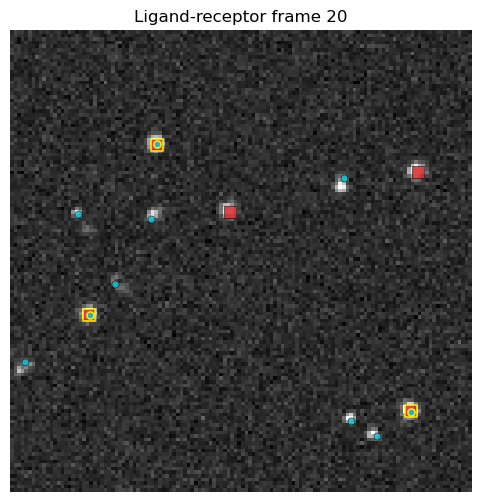

In [ ]:
plot_ligand_receptor_frame(sim, frame_id=20, show_ids=False)

In [15]:
sim.animate(interval=100, vmax=np.percentile(frames, 99.8))

## II. Regular vs masked tracking comparison

The comparison below keeps the simulation, peak extraction, cost defaults, and ligand-friendly tracking parameters fixed. The only experimental difference is whether a conservative static-receptor pass is used to remove receptor peaks before tracking the mobile population.


In [ ]:
METHOD_ORDER = ["Regular pipeline", "Separated pipeline"]
METHOD_COLORS = {
    "Regular pipeline": "#4c78a8",
    "Separated pipeline": "#f58518",
}
TYPE_COLORS = {
    "ligand": "#1f9e89",
    "receptor": "#d1495b",
    "unassigned": "#6b7280",
}

EVALUATION_TOLERANCE_PX = 1.25
REPORT_DIR = Path("Experiments")
REPORT_DIR.mkdir(exist_ok=True)
REPORT_FIGURE_BASE = REPORT_DIR / "LigandReceptor_tracking_comparison"
FRAME_FOR_FIGURE = min(20, simulation_config["nframes"] - 1)

PEAK_EXTRACTION_KWARGS = {
    "mode": "localization",
    "detection_threshold": 300,
    "r_squared_threshold": 0.35,
    "verbose_loc": False,
    "visualization_loc": False,
}

STATIC_COST = PeakToPeak(terms={
    "distance": DistanceTerm(weight=0.75, norm=2.0),
    "sigma": SigmaTerm(weight=0.25, norm=0.25),
})

STATIC_PASS_KWARGS = {
    "mode": "localization",
    "detection_threshold": 450,
    "r_squared_threshold": 0.5,
    "max_distance": 1.5,
    "min_length": 30,
    "max_gap": 0,
    "algo_peak2peak": "hungarian",
    "cost_func_peak2peak": STATIC_COST,
    "algo_traj2traj": "hungarian",
    "cost_func_traj2traj": None,
    "verbose_assignment": False,
}

MOBILE_TRACKING_KWARGS = {
    "max_distance": 14,
    "min_length": 2,
    "max_gap": 3,
    "stitch_fragments": True,
    "stitch_max_gap": 8,
    "stitch_base_distance": 12,
    "stitch_kwargs": {"max_link_cost": 2.5, "gap_weight": 0.05}, # favors stitching over short gap closing, and allows stitching of more distant fragments
    "verbose_stitching": False,
    "algo_peak2peak": "hungarian",
    "cost_func_peak2peak": None,
    "algo_traj2traj": "hungarian",
    "cost_func_traj2traj": None,
    "verbose_assignment": False,
}

In [ ]:
# Extract peaks once so both methods start from the same detections.
peaks_for_tracking = extract_peaks(frames, **PEAK_EXTRACTION_KWARGS)
print(f"Common localized peaks: {count_peaks(peaks_for_tracking)}")

# Regular pipeline: run ligand-friendly tracking on all localized peaks.
regular_trajs, regular_cost_peak2peak, regular_assignment, regular_cost_traj2traj = track_from_peaks(
    copy.deepcopy(peaks_for_tracking),
    trajectories_GT,
    **MOBILE_TRACKING_KWARGS,
)

regular_metrics = evaluate_tracking_method(
    "Regular pipeline",
    regular_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

print(f"Regular pipeline tracking: {len(regular_trajs)} final trajectories")
print(f"  peak-to-peak cost frames: {len(regular_cost_peak2peak)}")
print(f"  GT assignment cost: {regular_cost_traj2traj:.3f}")


Common localized peaks: 1206
Regular full tracking: 48 final trajectories
  peak-to-peak cost frames: 99
  GT assignment cost: 21.288


In [ ]:
# Separated pipeline.
# 1) Conservative pass finds long, nearly static receptor candidates.
static_results = sim.track(**STATIC_PASS_KWARGS)
static_candidate_trajs = copy.deepcopy(static_results[0])

static_candidate_metrics = evaluate_tracking_method(
    "Static pass",
    static_candidate_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

static_candidate_table = (
    static_candidate_metrics["tracks"]
    .groupby("type", dropna=False)
    .agg(n_tracks=("track_idx", "count"), median_error_px=("median_error_px", "median"))
    .reset_index()
)

print(f"Static pass candidates: {len(static_candidate_trajs)}")
display(static_candidate_table)

# 2) Remove those static peaks from the common peak list.
masked_peaks_for_tracking = remove_static_peaks(
    copy.deepcopy(peaks_for_tracking),
    static_candidate_trajs,
    tolerance=EVALUATION_TOLERANCE_PX,
    verbose=False,
)

removed_peaks = count_peaks(peaks_for_tracking) - count_peaks(masked_peaks_for_tracking)
print(f"Peaks removed by the static mask: {removed_peaks}")
print(f"Peaks kept for mobile tracking: {count_peaks(masked_peaks_for_tracking)}")

# 3) Track remaining mobile peaks with the same parameters as the regular pipeline.
masked_mobile_trajs, masked_mobile_cost_peak2peak, _, _ = track_from_peaks(
    copy.deepcopy(masked_peaks_for_tracking),
    trajectories_GT,
    **MOBILE_TRACKING_KWARGS,
)

# 4) Add the static candidates back, then assign the combined output to GT once.
masked_combined_trajs = copy.deepcopy(masked_mobile_trajs) + copy.deepcopy(static_candidate_trajs)
masked_combined_trajs, masked_cost_traj2traj, masked_assignment = assign_trajectories(
    masked_combined_trajs,
    trajectories_GT,
    cost_function=None,
    verbose=False,
)

masked_metrics = evaluate_tracking_method(
    "Separated pipeline",
    masked_combined_trajs,
    trajectories_GT,
    tolerance=EVALUATION_TOLERANCE_PX,
)

print(f"Separated pipeline tracking: {len(masked_combined_trajs)} final trajectories")
print(f"  mobile peak-to-peak cost frames: {len(masked_mobile_cost_peak2peak)}")
print(f"  combined GT assignment cost: {masked_cost_traj2traj:.3f}")


Static pass candidates: 5


,type,n_tracks,median_error_px
0,receptor,5,0.570092


Peaks removed by the static mask: 500
Peaks kept for mobile tracking: 706
Masked static-first tracking: 50 final trajectories
  mobile peak-to-peak cost frames: 99
  combined GT assignment cost: 20.812


In [ ]:
summary_table = combined_summary_table(regular_metrics, masked_metrics)
summary_display = summary_table.copy()
for col in ["mean_coverage_pct", "mean_good_fragments", "median_error_px", "within_tolerance_pct"]:
    summary_display[col] = summary_display[col].round(2)

display(summary_display)

state_summary = (
    pd.concat([regular_metrics["states"], masked_metrics["states"]], ignore_index=True)
    .groupby(["method", "type", "state"], as_index=False)
    .agg(
        n_frames=("n_frames", "sum"),
        recovered_frames=("recovered_frames", "sum"),
    )
)
state_summary["coverage_pct"] = 100 * state_summary["recovered_frames"] / state_summary["n_frames"]
display(state_summary.round({"coverage_pct": 2}))

print("Method differences, separated minus regular:")
for population in ["all", "ligand", "receptor"]:
    regular_row = summary_table[(summary_table["method"] == "Regular pipeline") & (summary_table["population"] == population)].iloc[0]
    masked_row = summary_table[(summary_table["method"] == "Separated pipeline") & (summary_table["population"] == population)].iloc[0]
    delta_cov = masked_row["mean_coverage_pct"] - regular_row["mean_coverage_pct"]
    delta_err = masked_row["median_error_px"] - regular_row["median_error_px"]
    delta_tracks = masked_row["tracks"] - regular_row["tracks"]
    print(
        f"  {population:8s}: coverage {delta_cov:+.1f} pp, "
        f"median error {delta_err:+.2f} px, tracks {delta_tracks:+.0f}"
    )


,method,population,gt_count,tracks,unassigned_tracks,mean_coverage_pct,recovered_gt_ge50,mean_good_fragments,median_error_px,within_tolerance_pct
0,Regular full,all,15,48,33,47.53,5,0.87,0.65,81.86
1,Regular full,ligand,10,10,0,29.50,1,0.80,1.51,67.51
2,Regular full,receptor,5,5,0,83.60,4,1.00,0.57,96.31
3,Masked static-first,all,15,50,35,49.13,5,0.87,0.63,84.62
4,Masked static-first,ligand,10,10,0,23.70,0,0.80,1.84,63.88
5,Masked static-first,receptor,5,5,0,100.00,5,1.00,0.57,100.00


,method,type,state,n_frames,recovered_frames,coverage_pct
0,Masked static-first,ligand,bound,334,0,0.00
1,Masked static-first,ligand,free,666,237,35.59
2,Masked static-first,receptor,bound,334,334,100.00
3,Masked static-first,receptor,free,166,166,100.00
4,Regular full,ligand,bound,334,60,17.96
5,Regular full,ligand,free,666,235,35.29
6,Regular full,receptor,bound,334,264,79.04
7,Regular full,receptor,free,166,154,92.77


Method differences, masked minus regular:
  all     : coverage +1.6 pp, median error -0.01 px, tracks +2
  ligand  : coverage -5.8 pp, median error +0.33 px, tracks +0
  receptor: coverage +16.4 pp, median error -0.00 px, tracks +0


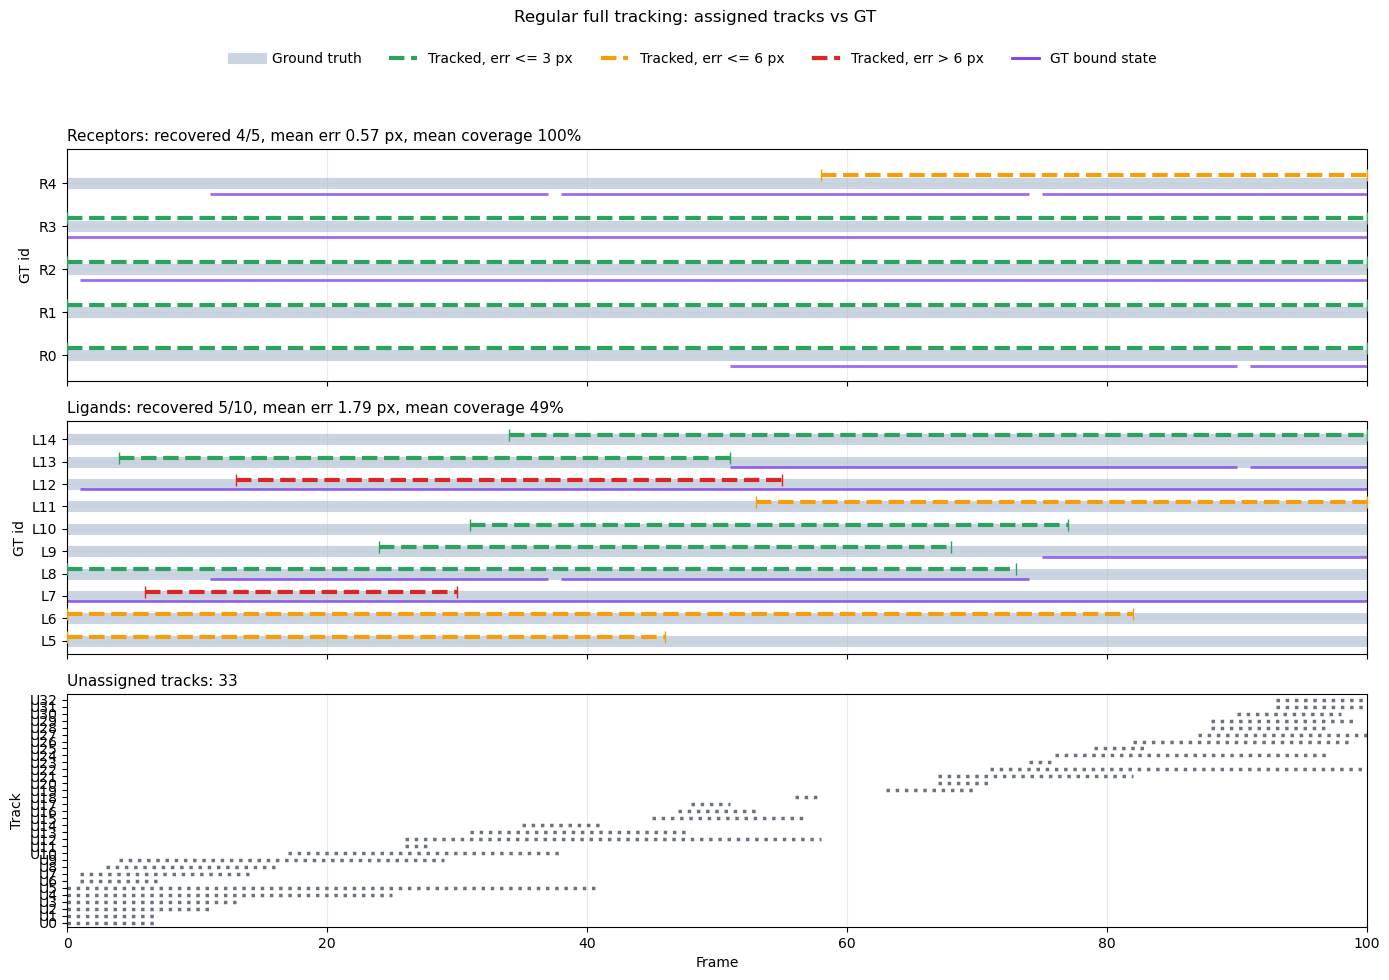

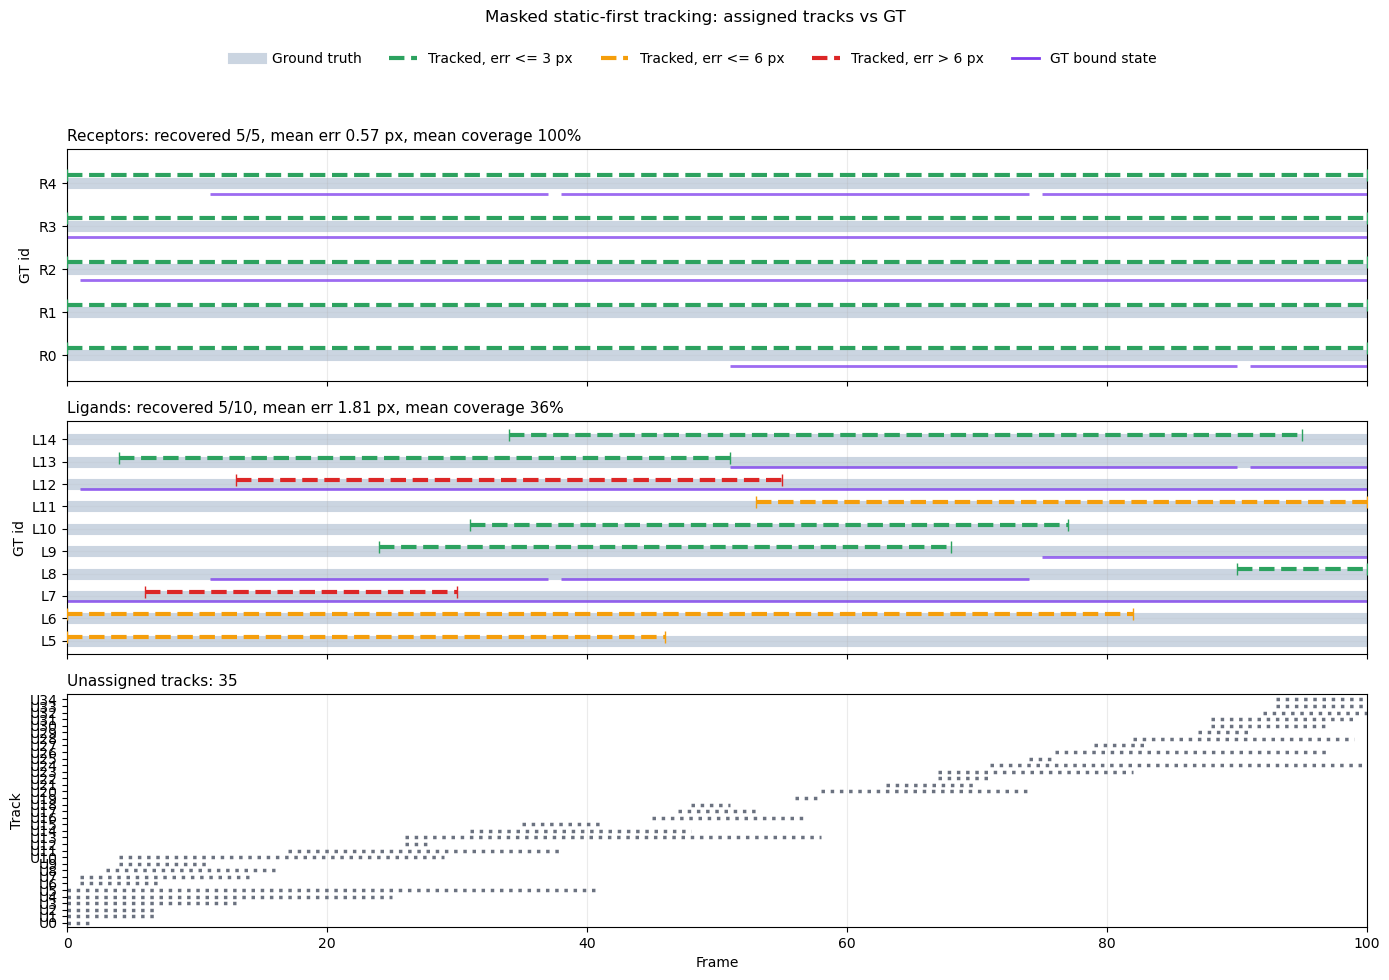

In [ ]:
linear_trajectories_visualizer(
    regular_trajs,
    trajectories_GT,
    quality_tolerance=EVALUATION_TOLERANCE_PX,
    show_labels=False,
    title="Regular pipeline: assigned tracks vs GT",
)

linear_trajectories_visualizer(
    masked_combined_trajs,
    trajectories_GT,
    quality_tolerance=EVALUATION_TOLERANCE_PX,
    show_labels=False,
    title="Separated pipeline: assigned tracks vs GT",
)


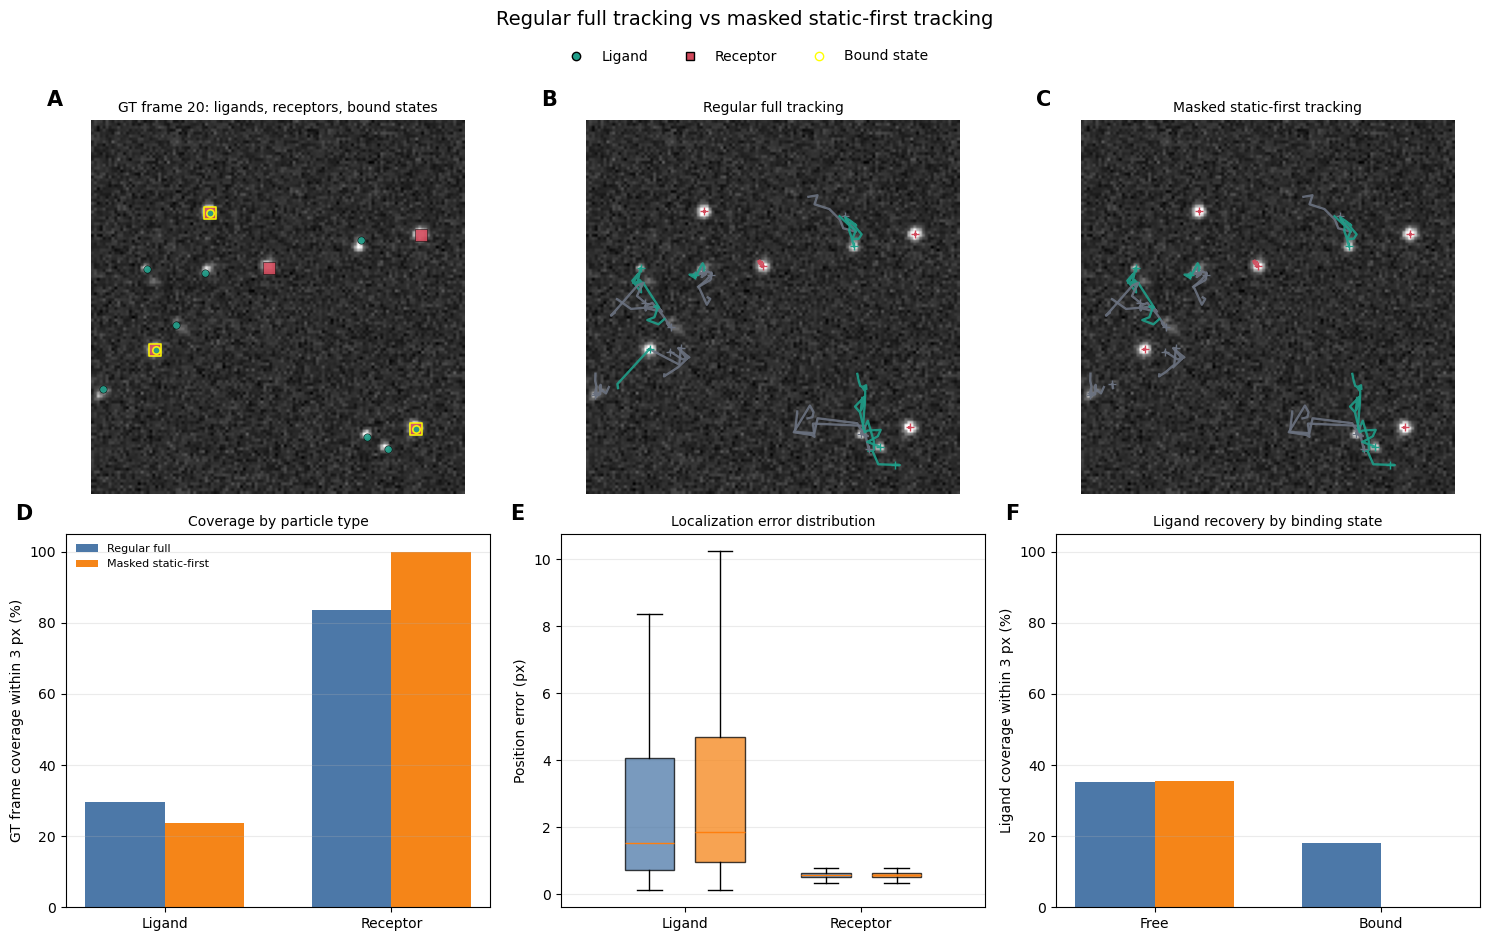

Saved report figure to Experiments\LigandReceptor_tracking_comparison_key_panels.png
Saved report figure to Experiments\LigandReceptor_tracking_comparison_key_panels.pdf


In [ ]:
fig = plot_ligand_receptor_comparison_figure()
plt.show()
print(f"Saved report figure to {REPORT_FIGURE_BASE.with_suffix('.png')}")
print(f"Saved report figure to {REPORT_FIGURE_BASE.with_suffix('.pdf')}")
